In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [3]:
from package_files.benefits_defns import *

In [4]:
from package_files.logit_model import *

In [5]:
# set font
plt.rcParams.update({'font.size': 14})

In [6]:
usdf_salary = pd.read_parquet('../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip')

In [7]:
# rename usdf_salary
usdf = usdf_salary

In [8]:
len(usdf)

9872916

In [8]:
usdf.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'SALARY', 'EXPIRED', 'DURATION',
       'AI ROLE', 'wfh_wham_prob', 'wfh_wham', 'YEAR', 'EDU_ASSISTANCE',
       'PAID_LEAVE', 'WELLBEING', 'HEALTH_WELLBEING', 'PARENTAL_LEAVE',
       'CULTURE', 'REMOTE_KW', 'EXPERIENCE_BUCKET', 'LOG_SALARY'],
      dtype='object')

In [ ]:
# usdf['HAS_SALARY_INFO'] = usdf.apply(lambda x: 1 if pd.notnull(x['SALARY']) else 0, axis=1)

In [11]:
usdf['HAS_SALARY_INFO'] = usdf['SALARY'].notnull().astype(int)

In [ ]:
# usdf['HAS_SALARY_INFO'] = np.where(usdf['SALARY'].notnull(), 1, 0)

In [ ]:
# usdf.rename(columns = {'has_salary_info': 'HAS_SALARY_INFO'}, inplace=True)

In [22]:
benefits4

['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'REMOTE_KW']

In [21]:
benefit_colors

{'EDU_ASSISTANCE': '#41afaa',
 'PAID_LEAVE': '#466eb4',
 'HEALTH_WELLBEING': '#e6a532',
 'PARENTAL_LEAVE': '#00a0e1',
 'CULTURE': '#d7642c',
 'wfh_wham': '#af4b91',
 'REMOTE_KW': '#c765a6'}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   EDU_ASSISTANCE   28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
EDU_ASSISTANCE     0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,EDU_ASSISTANCE,HAS_SALARY_INFO
0,2018,False,False,0.160961
1,2018,False,True,0.151038
2,2018,True,False,0.068281
3,2018,True,True,0.049145
4,2019,False,False,0.184433


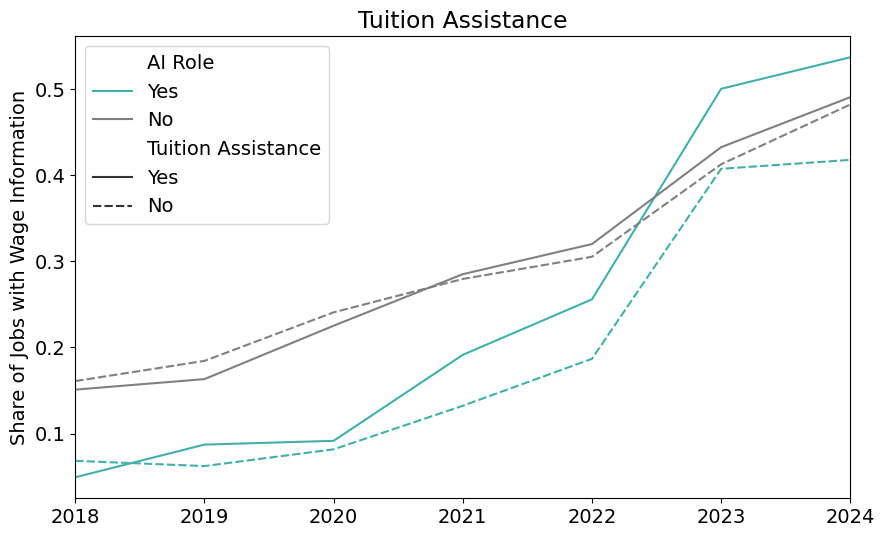

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   PAID_LEAVE       28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
PAID_LEAVE         0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,PAID_LEAVE,HAS_SALARY_INFO
0,2018,False,False,0.149523
1,2018,False,True,0.250293
2,2018,True,False,0.059673
3,2018,True,True,0.164076
4,2019,False,False,0.168259


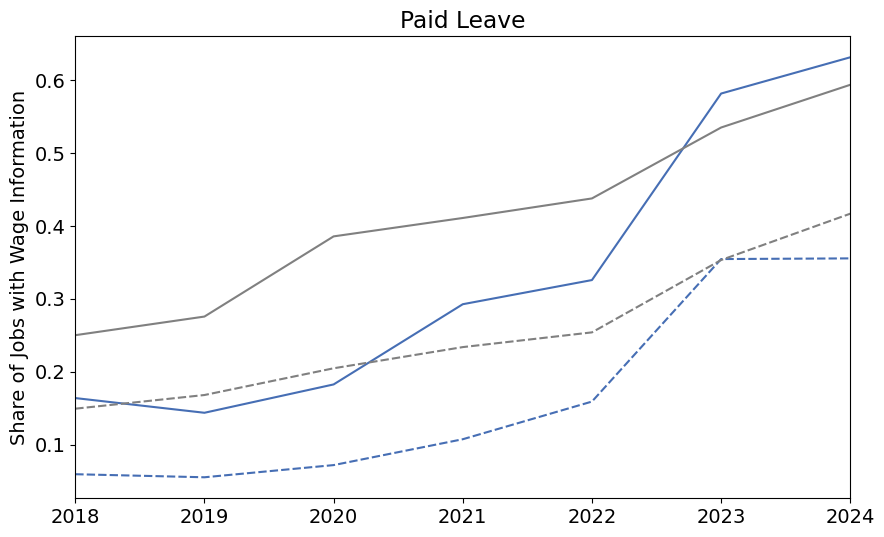

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              28 non-null     int32  
 1   AI ROLE           28 non-null     bool   
 2   HEALTH_WELLBEING  28 non-null     bool   
 3   HAS_SALARY_INFO   28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR                0
AI ROLE             0
HEALTH_WELLBEING    0
HAS_SALARY_INFO     0
dtype: int64


,YEAR,AI ROLE,HEALTH_WELLBEING,HAS_SALARY_INFO
0,2018,False,False,0.159401
1,2018,False,True,0.211550
2,2018,True,False,0.067349
3,2018,True,True,0.088983
4,2019,False,False,0.183209


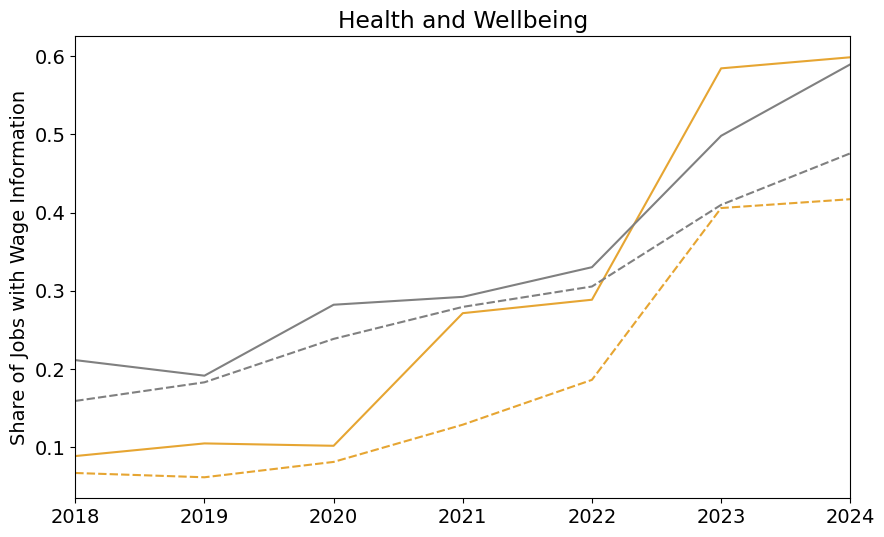

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   PARENTAL_LEAVE   28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
PARENTAL_LEAVE     0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,PARENTAL_LEAVE,HAS_SALARY_INFO
0,2018,False,False,0.160727
1,2018,False,True,0.125307
2,2018,True,False,0.068037
3,2018,True,True,0.033113
4,2019,False,False,0.183044


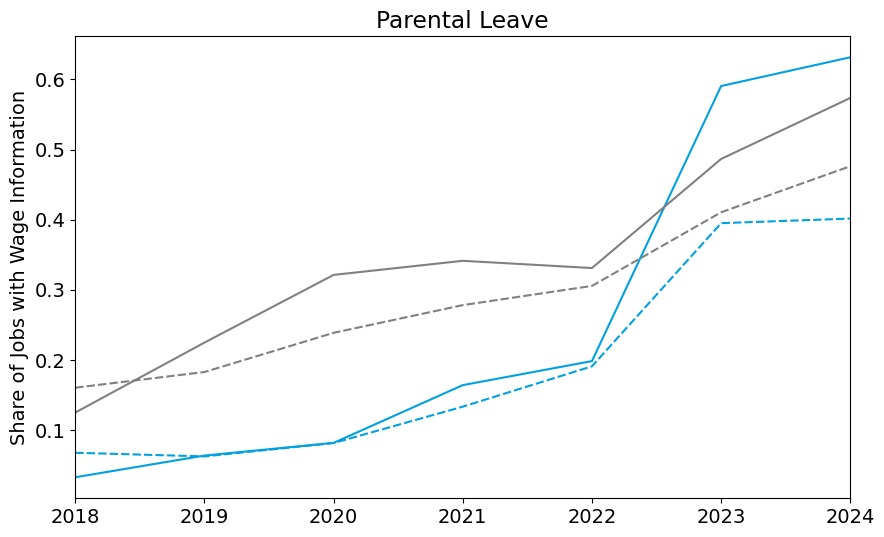

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   CULTURE          28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
CULTURE            0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,CULTURE,HAS_SALARY_INFO
0,2018,False,False,0.163536
1,2018,False,True,0.094976
2,2018,True,False,0.071517
3,2018,True,True,0.026985
4,2019,False,False,0.187764


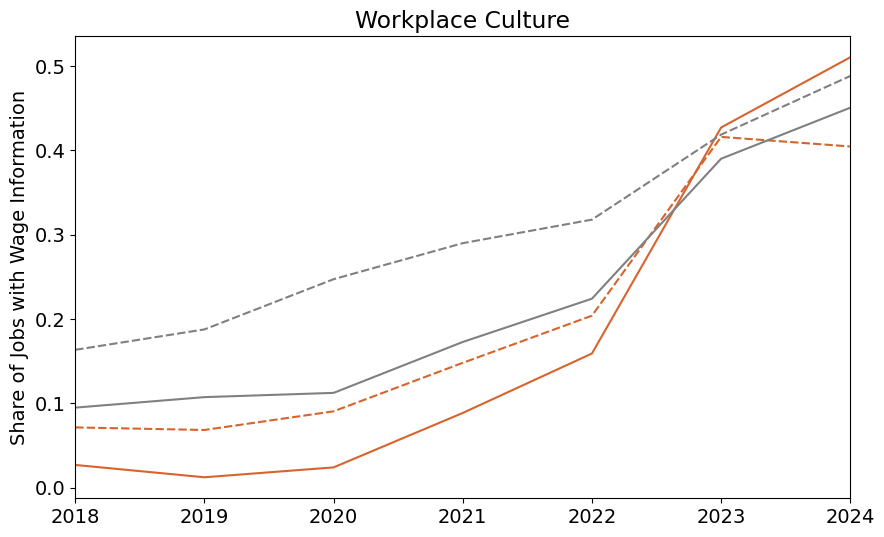

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   REMOTE_KW        28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
REMOTE_KW          0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,REMOTE_KW,HAS_SALARY_INFO
0,2018,False,False,0.159121
1,2018,False,True,0.213726
2,2018,True,False,0.066310
3,2018,True,True,0.107784
4,2019,False,False,0.179030


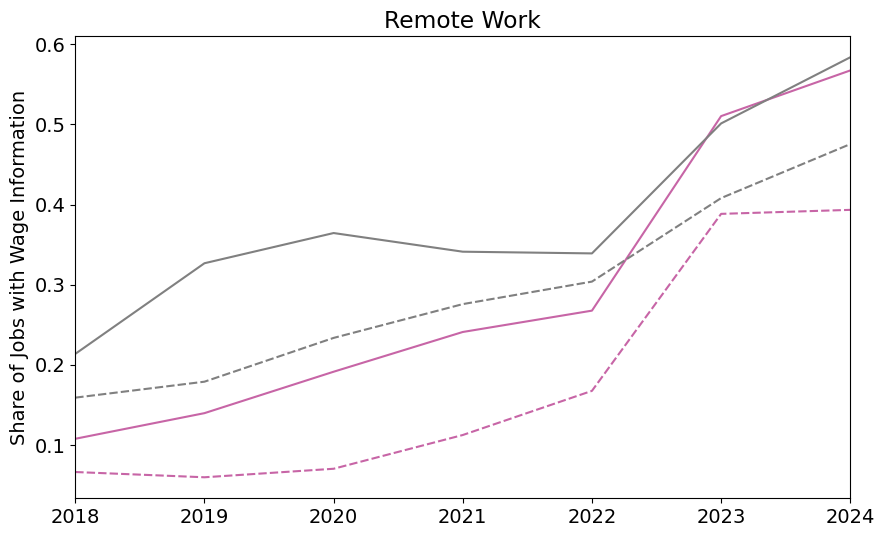

In [39]:
for benefit in benefits4:
    grouped = usdf.groupby(['YEAR','AI ROLE', benefit])['HAS_SALARY_INFO'].mean().reset_index()
    grouped['HAS_SALARY_INFO'] = pd.to_numeric(grouped['HAS_SALARY_INFO'], errors='coerce')
    print(grouped.info())
    grouped['YEAR'] = pd.to_numeric(grouped['YEAR'], errors = 'coerce')
    grouped['YEAR'].unique()
    grouped['AI ROLE'] = grouped['AI ROLE'].astype(str)
    grouped[benefit] = grouped[benefit].astype(str)
    grouped = grouped.sort_values('YEAR')
    print(grouped['YEAR'].unique())
    print(grouped.isnull().sum())
    palette = [benefit_colors[benefit], 'gray']
    display(grouped.head())
    
    plt.figure(figsize = (10,6))
    sns.lineplot(
        data = grouped,
        x = 'YEAR', 
        y = 'HAS_SALARY_INFO', 
        hue = 'AI ROLE',
        style = benefit,
        # markers=False,
        errorbar = None, 
        palette=palette,
        style_order = ['True', 'False'],
        hue_order=['True','False']
    )
    plt.xticks(grouped['YEAR'].unique())
    plt.xlim(grouped['YEAR'].min(), grouped['YEAR'].max())
    handles, labels = plt.gca().get_legend_handles_labels()
    new_handles = handles
    new_labels = ['AI Role', 'Yes','No', f'{benefits_labels_map[benefit]}','Yes','No']
    if benefit == benefits4[0]:
        plt.legend(handles = new_handles, labels = new_labels, loc='upper left')
    else: 
        plt.legend().remove()
    plt.xlabel(None)
    plt.ylabel('Share of Jobs with Wage Information')    
    plt.title(benefits_labels_map[benefit])
    fig_path = '../figures/salary/wage_info'
    if not os.path.exists(fig_path):
        os.makedirs(fig_path)
    plt.savefig(fig_path + f'/wage_info_{benefit}.png')
    plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   EDU_ASSISTANCE   28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int32  
 1   AI ROLE          28 non-null     bool   
 2   PAID_LEAVE       28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int32(1)
memory usage: 524.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #  

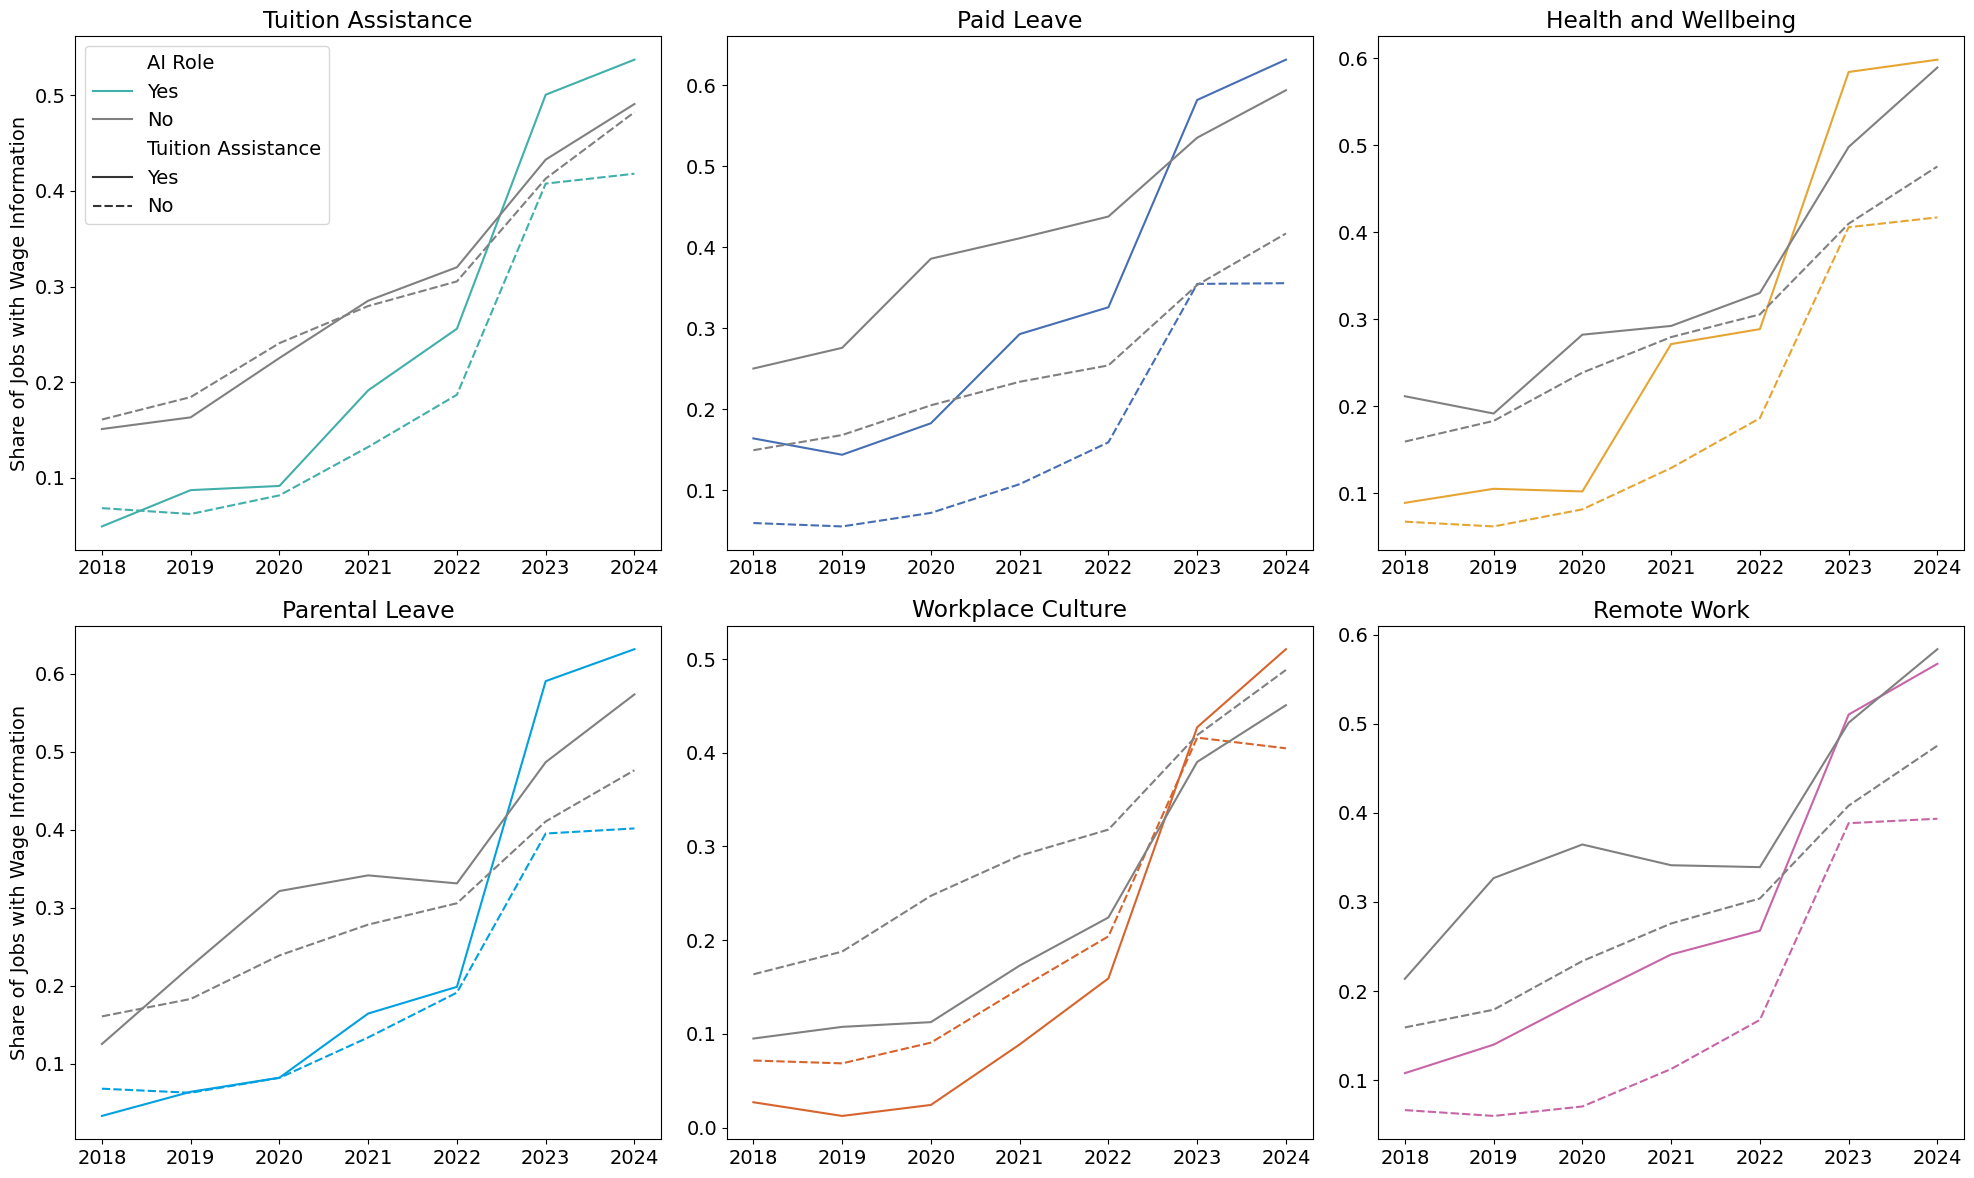

In [ ]:
# Define the number of rows and columns for subplots
nrows = 2
ncols = 3

# Set up the overall figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to easily index axes

for i, benefit in enumerate(benefits4):
    ax = axes[i]
    grouped = usdf.groupby(['YEAR','AI ROLE', benefit])['HAS_SALARY_INFO'].mean().reset_index()
    grouped['HAS_SALARY_INFO'] = pd.to_numeric(grouped['HAS_SALARY_INFO'], errors='coerce')
    # print(grouped.info())
    grouped['YEAR'] = pd.to_numeric(grouped['YEAR'], errors = 'coerce')
    grouped['YEAR'].unique()
    grouped['AI ROLE'] = grouped['AI ROLE'].astype(str)
    grouped[benefit] = grouped[benefit].astype(str)
    grouped = grouped.sort_values('YEAR')
    # print(grouped['YEAR'].unique())
    # print(grouped.isnull().sum())
    palette = [benefit_colors[benefit], 'gray']
    # display(grouped.head())
    
    sns.lineplot(
        data = grouped,
        x = 'YEAR', 
        y = 'HAS_SALARY_INFO', 
        hue = 'AI ROLE',
        style = benefit,
        # markers=False,
        errorbar = None, 
        palette=palette,
        style_order = ['True', 'False'],
        hue_order=['True','False'], 
        ax = ax
    )
    ax.set_xticks(grouped['YEAR'].unique())
    ax.set_xlabel(None)
    if i == 0 or i == 3:
        ax.set_ylabel('Share of Jobs with Wage Information')
    else:
        ax.set_ylabel(None)
    ax.set_title(benefits_labels_map[benefit])

    # Customize legend for each subplot
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ['AI Role', 'Yes', 'No', f'{benefits_labels_map[benefit]}', 'Yes', 'No']
        ax.legend(handles=handles, labels=new_labels, loc='upper left')
    else:
        ax.legend().remove()
    
plt.tight_layout()
plt.savefig(fig_path + '/wage_info_all.png')
plt.show()


# Models

In [16]:
models = []
model_data = usdf[usdf['YEAR'] == 2023]
for benefit in benefits4:
    model = run_logit_model(data = model_data, dependent = 'HAS_SALARY_INFO', predictor = 'AI ROLE', binary_vars = [benefit])
    models.append(model)
    model.summary()

Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.678599
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        HAS_SALARY_INFO   No. Observations:              1485795
Model:                          Logit   Df Residuals:                  1485792
Method:                           MLE   Df Model:                            2
Date:                Mon, 09 Dec 2024   Pseudo R-squ.:               0.0001280
Time:                        19:19:33   Log-Likelihood:            -1.0083e+06
converged:                       True   LL-Null:                   -1.0084e+06
Covariance Type:            nonrobust   LLR p-value:                 9.130e-57
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.3522      0.002   -198.439      0.000      -0.356

                           Logit Regression Results                           
Dep. Variable:        HAS_SALARY_INFO   No. Observations:              1485795
Model:                          Logit   Df Residuals:                  1485792
Method:                           MLE   Df Model:                            2
Date:                Mon, 09 Dec 2024   Pseudo R-squ.:                 0.02245
Time:                        19:19:35   Log-Likelihood:            -9.8575e+05
converged:                       True   LL-Null:                   -1.0084e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6051      0.002   -285.226      0.000      -0.609      -0.601
AI ROLE        0.0602      0.016      3.881      0.000       0.030       0.091
PAID_LEAVE     0.7467      0.004    211.765      0.0

In [17]:
stargazer = Stargazer(models)
stargazer.render_latex()



'\\begin{table}[!htbp] \\centering\n\\begin{tabular}{@{\\extracolsep{5pt}}lcccccc}\n\\\\[-1.8ex]\\hline\n\\hline \\\\[-1.8ex]\n& \\multicolumn{6}{c}{\\textit{Dependent variable: HAS_SALARY_INFO}} \\\n\\cr \\cline{2-7}\n\\\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\\\\n\\hline \\\\[-1.8ex]\n AI ROLE & 0.015$^{}$ & 0.060$^{***}$ & 0.011$^{}$ & -0.004$^{}$ & 0.031$^{**}$ & -0.052$^{***}$ \\\\\n& (0.015) & (0.016) & (0.015) & (0.015) & (0.015) & (0.015) \\\\\n CULTURE & & & & & -0.115$^{***}$ & \\\\\n& & & & & (0.005) & \\\\\n EDU_ASSISTANCE & 0.085$^{***}$ & & & & & \\\\\n& (0.005) & & & & & \\\\\n HEALTH_WELLBEING & & & 0.362$^{***}$ & & & \\\\\n& & & (0.007) & & & \\\\\n PAID_LEAVE & & 0.747$^{***}$ & & & & \\\\\n& & (0.004) & & & & \\\\\n PARENTAL_LEAVE & & & & 0.319$^{***}$ & & \\\\\n& & & & (0.007) & & \\\\\n REMOTE_KW & & & & & & 0.381$^{***}$ \\\\\n& & & & & & (0.006) \\\\\n const & -0.352$^{***}$ & -0.605$^{***}$ & -0.365$^{***}$ & -0.362$^{***}$ & -0.328$^{***}$ & -0.372$^{*

In [18]:
with open(f'../exports/tables/wage_info_2023.tex', 'w') as f:
    f.write(stargazer.render_latex())

In [19]:
display(HTML(stargazer.render_html()))

In [21]:
usdf[usdf['AI ROLE']==True]

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,PAID_LEAVE,WELLBEING,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW,EXPERIENCE_BUCKET,LOG_SALARY,HAS_SALARY_INFO
128,2d0820331da990677cf77d3783154bd85bb53af4,"Flowery Branch, GA","Hall, GA",Georgia,99,Unclassified Industry,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,3-5 years,NaN,0
182,f556cbda366e9d0b2771fd4019fd2e6f088f2896,"Miami, FL","Miami-Dade, FL",Florida,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,True,3-5 years,NaN,0
187,fabd120b46616c18c8fea9c6005c13089081d0df,"Austin, TX","Williamson, TX",Texas,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,6-10 years,NaN,0
244,39cd7682488f13bd227c68f1c3d9ce835fa982ee,"Little Rock, AR","Pulaski, AR",Arkansas,44,Retail Trade,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,True,3-5 years,NaN,0
256,32112b12427b335ba8c7d703b8a4def02a551725,"Tampa, FL","Hillsborough, FL",Florida,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,3-5 years,11.950922,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9872495,d295fdb9b20071ad1b70d3d9e19b544b56e0b742,"Tukwila, WA","King, WA",Washington,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,False,6-10 years,NaN,0
9872638,8872bc2cdefa891c1dc931d99aa09168afd57504,"Wright-Patterson Air Force Base, OH","Greene, OH",Ohio,54,"Professional, Scientific, and Technical Services",Associate degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,11-20 years,NaN,0
9872696,6b6d64a0a35b38b1d80d1797dd5d2a3c3d3a9629,"North Chicago, IL","Lake, IL",Illinois,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,3-5 years,NaN,0
9872890,c77b918f92613d85a300bd67f026291a17915585,"Knoxville, TN","Knox, TN",Tennessee,52,Finance and Insurance,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,6-10 years,NaN,0


## Only AI Roles

In [13]:
models2 = []
model_data_ai = usdf[(usdf['YEAR'] == 2023) & ( usdf['AI ROLE'] == True)]
for benefit in benefits4:
    model = run_logit_model(data = model_data_ai, dependent = 'HAS_SALARY_INFO', predictor = benefit)
    models2.append(model)
    model.summary()

Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.678097
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        HAS_SALARY_INFO   No. Observations:                17766
Model:                          Logit   Df Residuals:                    17764
Method:                           MLE   Df Model:                            1
Date:                Mon, 09 Dec 2024   Pseudo R-squ.:                0.002751
Time:                        20:53:33   Log-Likelihood:                -12047.
converged:                       True   LL-Null:                       -12080.
Covariance Type:            nonrobust   LLR p-value:                 3.555e-16
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.3734      0.016    -22.925      0.000      -0.405

In [14]:
stargazer = Stargazer(models2)
stargazer.render_latex()

'\\begin{table}[!htbp] \\centering\n\\begin{tabular}{@{\\extracolsep{5pt}}lcccccc}\n\\\\[-1.8ex]\\hline\n\\hline \\\\[-1.8ex]\n& \\multicolumn{6}{c}{\\textit{Dependent variable: HAS_SALARY_INFO}} \\\n\\cr \\cline{2-7}\n\\\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\\\\n\\hline \\\\[-1.8ex]\n CULTURE & & & & & 0.046$^{}$ & \\\\\n& & & & & (0.035) & \\\\\n EDU_ASSISTANCE & 0.376$^{***}$ & & & & & \\\\\n& (0.046) & & & & & \\\\\n HEALTH_WELLBEING & & & 0.722$^{***}$ & & & \\\\\n& & & (0.058) & & & \\\\\n PAID_LEAVE & & 0.928$^{***}$ & & & & \\\\\n& & (0.034) & & & & \\\\\n PARENTAL_LEAVE & & & & 0.792$^{***}$ & & \\\\\n& & & & (0.047) & & \\\\\n REMOTE_KW & & & & & & 0.496$^{***}$ \\\\\n& & & & & & (0.035) \\\\\n const & -0.373$^{***}$ & -0.599$^{***}$ & -0.381$^{***}$ & -0.426$^{***}$ & -0.339$^{***}$ & -0.454$^{***}$ \\\\\n& (0.016) & (0.019) & (0.016) & (0.016) & (0.018) & (0.018) \\\\\n\\hline \\\\[-1.8ex]\n Observations & 17766 & 17766 & 17766 & 17766 & 17766 & 17766 \\\\\n Pseud

In [15]:
display(HTML(stargazer.render_html()))

In [16]:
with open(f'../exports/tables/wage_info_2023_ai.tex', 'w') as f:
    f.write(stargazer.render_latex())